In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/food_delivery.csv')

for col in df.select_dtypes(include=['object', 'str']).columns:
    df[col] = df[col].str.strip()

print(df.shape)
print("--------------")
print(df.dtypes)

(45593, 20)
--------------
ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object


In [2]:
print(df.isnull().sum().sum())

0


In [3]:
for col in df.select_dtypes(include='str').columns:
    print(col, df[col].unique()[:10])

ID <ArrowStringArray>
['0x4607', '0xb379', '0x5d6d', '0x7a6a', '0x70a2', '0x9bb4', '0x95b4',
 '0x9eb2', '0x1102', '0xcdcd']
Length: 10, dtype: str
Delivery_person_ID <ArrowStringArray>
[  'INDORES13DEL02',   'BANGRES18DEL02',   'BANGRES19DEL01',
  'COIMBRES13DEL02',   'CHENRES12DEL01',    'HYDRES09DEL03',
 'RANCHIRES15DEL01',    'MYSRES15DEL02',    'HYDRES05DEL02',
    'DEHRES17DEL01']
Length: 10, dtype: str
Delivery_person_Age <ArrowStringArray>
['37', '34', '23', '38', '32', '22', '33', '35', '36', '21']
Length: 10, dtype: str
Delivery_person_Ratings <ArrowStringArray>
['4.9', '4.5', '4.4', '4.7', '4.6', '4.8', '4.2', '4.3', '4', '4.1']
Length: 10, dtype: str
Order_Date <ArrowStringArray>
['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022', '11-03-2022',
 '04-03-2022', '14-03-2022', '20-03-2022', '12-02-2022', '13-02-2022']
Length: 10, dtype: str
Time_Orderd <ArrowStringArray>
['11:30:00', '19:45:00', '08:30:00', '18:00:00', '13:30:00', '21:20:00',
 '19:15:00', '17:25:00', '20:55

In [4]:
disguised_nulls = df.apply(lambda col: col.astype(str).str.strip().str.contains('NaN').sum())
print(disguised_nulls[disguised_nulls > 0])

Delivery_person_Age        1854
Delivery_person_Ratings    1908
Time_Orderd                1731
Weatherconditions           616
Road_traffic_density        601
multiple_deliveries         993
Festival                    228
City                       1200
dtype: int64


In [5]:
for col in df.select_dtypes(include='str').columns:
    mask = df[col].str.contains('NaN', na=False)
    df.loc[mask, col] = np.nan

In [6]:
# Weatherconditions: "conditions Sunny" -> "Sunny"
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False)

# Time_taken(min): "(min) 24" -> 24 (int)
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '', regex=False).astype(float)

# numeric columns still stored as text
df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(float)
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].astype(float)
df['multiple_deliveries'] = df['multiple_deliveries'].astype(float)

In [7]:
# numeric imputation
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())

# mode imputation
for col in ['Weatherconditions', 'Road_traffic_density', 'multiple_deliveries', 'Festival', 'City']:
    df[col] = df[col].fillna(df[col].mode()[0])

# drop rows with missing order time
df = df.dropna(subset=['Time_Orderd'])
print(df.shape)

(43862, 20)


In [8]:
print(df[['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']].describe())

       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
count         43862.000000          43862.000000                43862.000000   
mean             17.241971             70.764932                   17.462466   
std               7.698686             21.136195                    7.338540   
min             -30.902872              0.000000                    0.010000   
25%              12.933298             73.170283                   12.986229   
50%              18.554382             75.898497                   18.633934   
75%              22.732225             78.045359                   22.785049   
max              30.914057             88.433452                   31.054057   

       Delivery_location_longitude  
count                 43862.000000  
mean                     70.828527  
std                      21.136365  
min                       0.010000  
25%                      73.279312  
50%                      75.999490  
75%                 

In [9]:
print(df['Time_taken(min)'].describe())

count    43862.000000
mean        26.293831
std          9.373765
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64


In [10]:
for col in ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']:
    df[col] = df[col].abs()

In [11]:
print(df.duplicated().sum())
print(df.shape)

0
(43862, 20)


In [12]:
mask = (
    (df['Restaurant_latitude'] < 1) | (df['Restaurant_longitude'] < 1) |
    (df['Delivery_location_latitude'] < 1) | (df['Delivery_location_longitude'] < 1)
)
print(mask.sum())
df = df[~mask]
print(df.shape)

3509
(40353, 20)


In [13]:
# numeric columns: mean, median, std
print(df.describe())

       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
count         40353.000000             40353.000000         40353.000000   
mean             29.554829                 4.634387            18.911836   
std               5.746713                 0.313975             5.468296   
min              20.000000                 2.500000             9.957144   
25%              25.000000                 4.500000            12.986047   
50%              30.000000                 4.700000            19.065838   
75%              35.000000                 4.900000            22.751234   
max              39.000000                 5.000000            30.914057   

       Restaurant_longitude  Delivery_location_latitude  \
count          40353.000000                40353.000000   
mean              76.918480                   18.975471   
std                3.500531                    5.470105   
min               72.768726                    9.967144   
25%               73

In [14]:
# categorical columns: frequency counts
categorical_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 
                     'Type_of_vehicle', 'Festival', 'City']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Weatherconditions:
Weatherconditions
Fog           6845
Stormy        6806
Cloudy        6747
Sandstorms    6717
Windy         6675
Sunny         6563
Name: count, dtype: int64

Road_traffic_density:
Road_traffic_density
Low       13816
Jam       12726
Medium     9836
High       3975
Name: count, dtype: int64

Type_of_order:
Type_of_order
Snack     10196
Meal      10119
Drinks    10059
Buffet     9979
Name: count, dtype: int64

Type_of_vehicle:
Type_of_vehicle
motorcycle          23660
scooter             13489
electric_scooter     3204
Name: count, dtype: int64

Festival:
Festival
No     39566
Yes      787
Name: count, dtype: int64

City:
City
Metropolitian    31279
Urban             8933
Semi-Urban         141
Name: count, dtype: int64


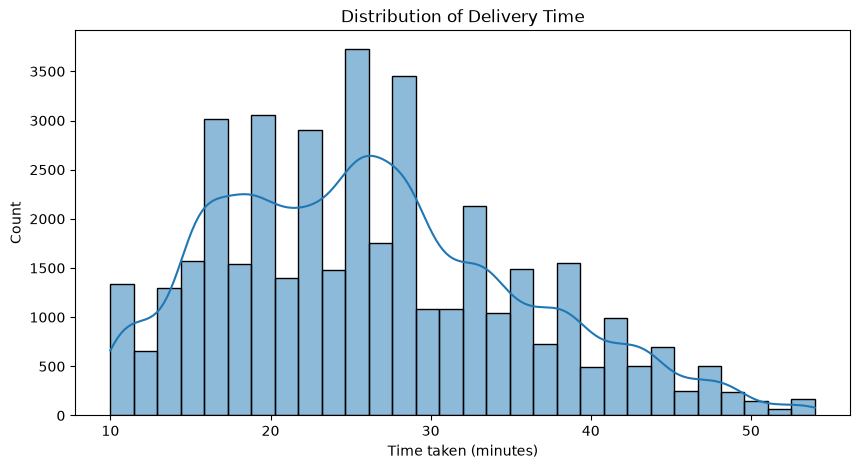

Skewness: 0.4785198260638503


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['Time_taken(min)'], bins=30, kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Time taken (minutes)')
plt.ylabel('Count')
plt.show()

print("Skewness:", df['Time_taken(min)'].skew())

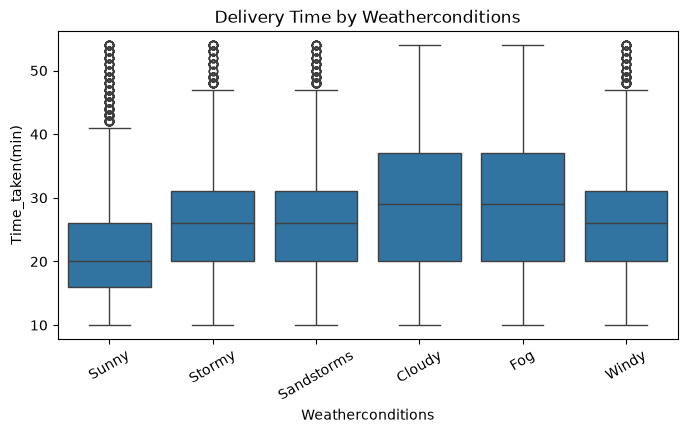

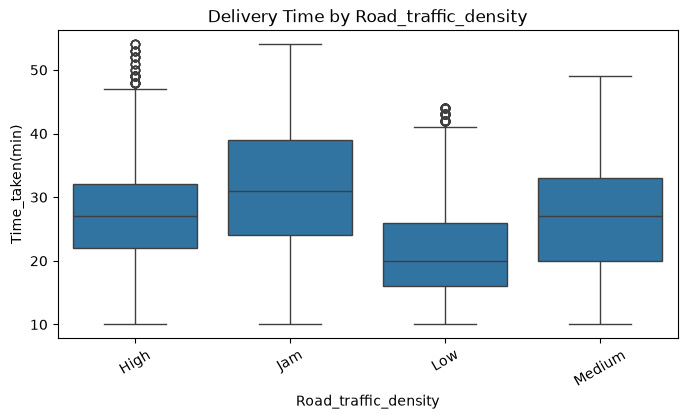

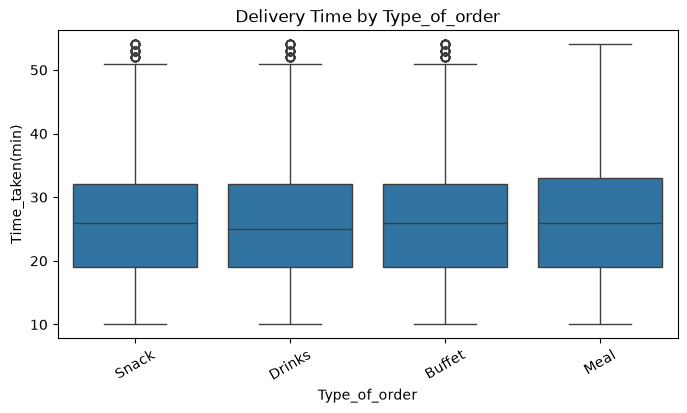

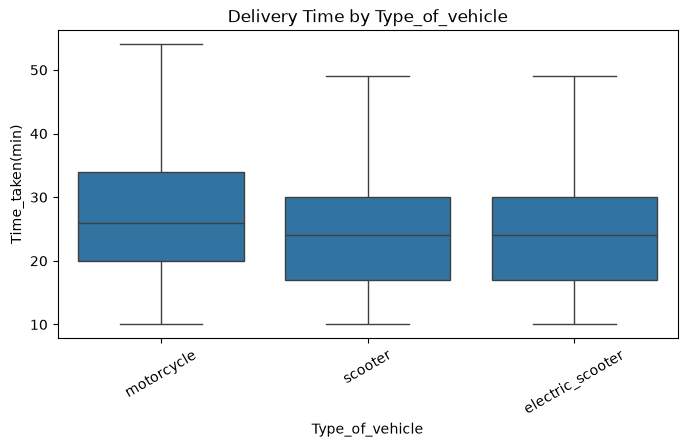

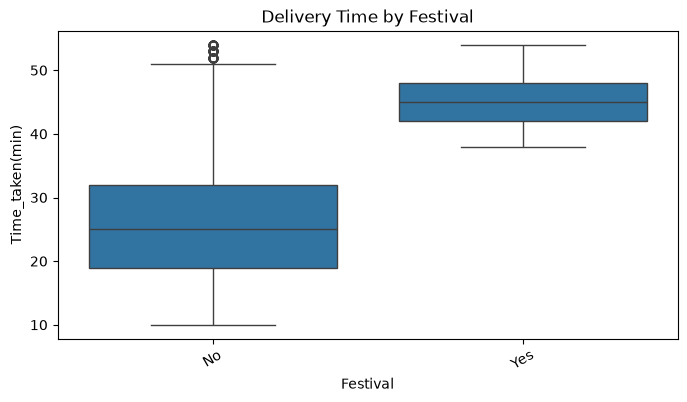

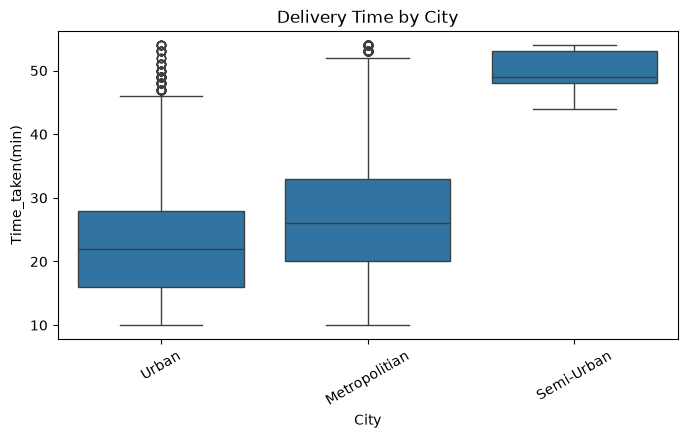

In [16]:
categorical_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 
                     'Type_of_vehicle', 'Festival', 'City']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col, y='Time_taken(min)')
    plt.title(f'Delivery Time by {col}')
    plt.xticks(rotation=30)
    plt.show()

In [17]:
print(df.groupby('City')['Time_taken(min)'].agg(['mean', 'count']))
print(df.groupby('Festival')['Time_taken(min)'].agg(['mean', 'count']))

                    mean  count
City                           
Metropolitian  27.141597  31279
Semi-Urban     49.680851    141
Urban          23.041196   8933
               mean  count
Festival                  
No        25.931557  39566
Yes       45.471410    787


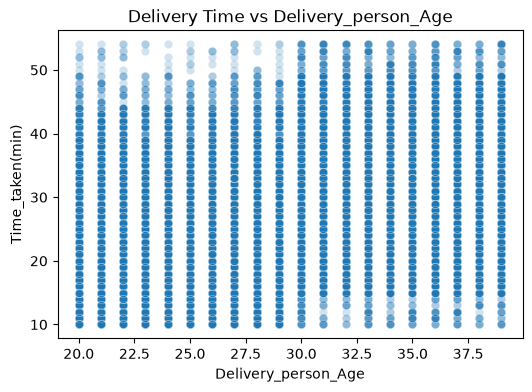

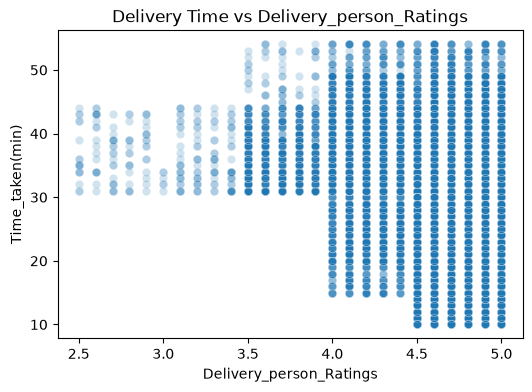

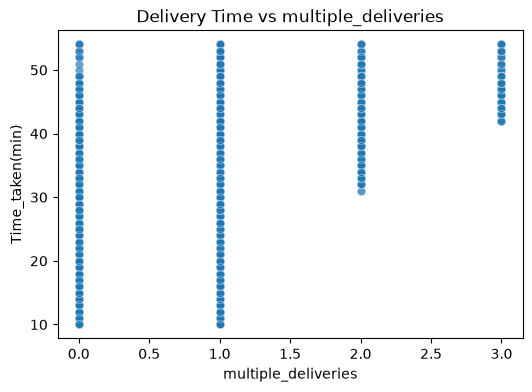

In [18]:
numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='Time_taken(min)', alpha=0.2)
    plt.title(f'Delivery Time vs {col}')
    plt.show()

In [19]:
print(df.groupby('multiple_deliveries')['Time_taken(min)'].agg(['mean', 'count']))
print(df['Delivery_person_Ratings'].value_counts().sort_index())

                          mean  count
multiple_deliveries                  
0.0                  22.890143  12489
1.0                  26.736187  25772
2.0                  40.425365   1782
3.0                  47.858065    310
Delivery_person_Ratings
2.5      18
2.6      20
2.7      21
2.8      17
2.9      18
3.0       6
3.1      28
3.2      26
3.3      23
3.4      32
3.5     236
3.6     194
3.7     203
3.8     218
3.9     176
4.0     998
4.1    1323
4.2    1331
4.3    1301
4.4    1246
4.5    3067
4.6    6387
4.7    6772
4.8    6558
4.9    6468
5.0    3666
Name: count, dtype: int64


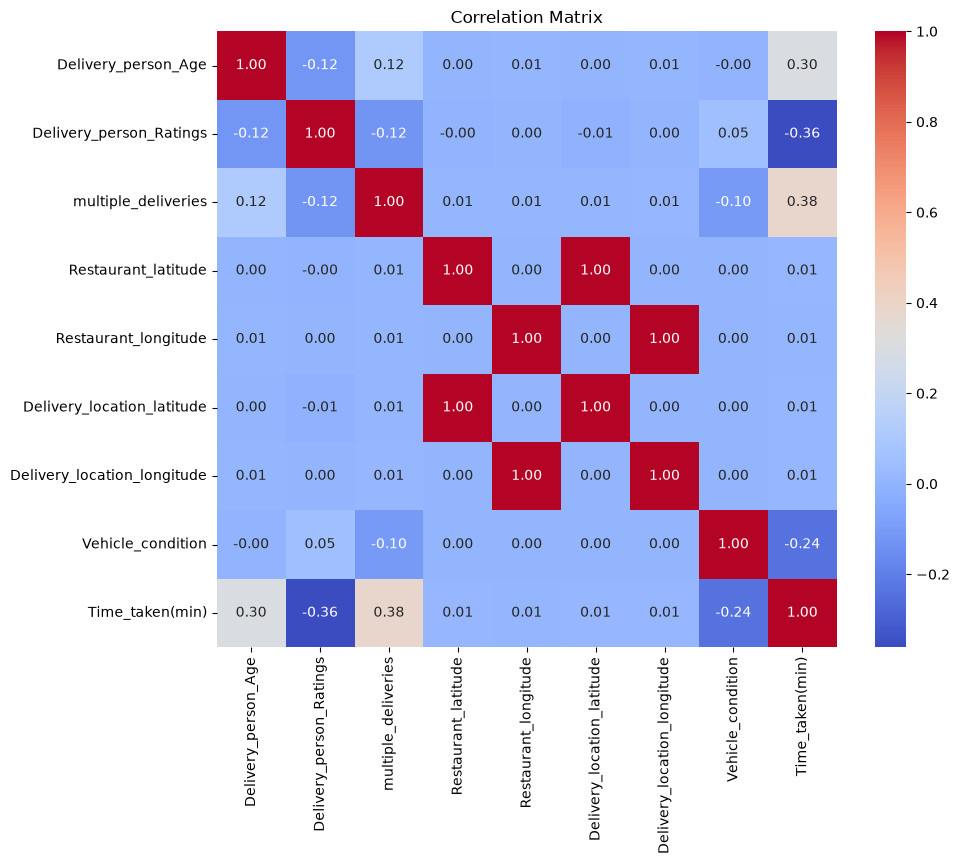

In [20]:
numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries',
                 'Restaurant_latitude', 'Restaurant_longitude', 
                 'Delivery_location_latitude', 'Delivery_location_longitude',
                 'Vehicle_condition', 'Time_taken(min)']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [21]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

df['distance_km'] = df.apply(
    lambda row: haversine(row['Restaurant_latitude'], row['Restaurant_longitude'],
                           row['Delivery_location_latitude'], row['Delivery_location_longitude']),
    axis=1
)

In [22]:
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S')

df['prep_time_min'] = (df['Time_Order_picked'] - df['Time_Orderd']).dt.total_seconds() / 60

# handle negative values (order picked up "before" ordered = crossed midnight)
df['prep_time_min'] = df['prep_time_min'].apply(lambda x: x + 1440 if x < 0 else x)

In [23]:
print(df[['distance_km', 'prep_time_min', 'Time_taken(min)']].corr())

                 distance_km  prep_time_min  Time_taken(min)
distance_km         1.000000       0.000603         0.321259
prep_time_min       0.000603       1.000000        -0.009563
Time_taken(min)     0.321259      -0.009563         1.000000


In [24]:
print(df['prep_time_min'].describe())

count    40353.000000
mean         9.978688
std          4.087331
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: prep_time_min, dtype: float64


In [25]:
# Ordinal: traffic has a real order
traffic_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
df['Road_traffic_density'] = df['Road_traffic_density'].map(traffic_order)

# Binary: Festival is just Yes/No
df['Festival'] = df['Festival'].map({'No': 0, 'Yes': 1})

# One-hot: no natural order
df = pd.get_dummies(df, columns=['Weatherconditions', 'Type_of_order', 'Type_of_vehicle', 'City'], drop_first=True)

In [26]:
df_model = df.drop(columns=['ID', 'Delivery_person_ID', 'Order_Date', 
                              'Time_Orderd', 'Time_Order_picked',
                              'Restaurant_latitude', 'Restaurant_longitude',
                              'Delivery_location_latitude', 'Delivery_location_longitude'])

In [27]:
print(df_model.shape)
print(df_model.dtypes)

(40353, 21)
Delivery_person_Age             float64
Delivery_person_Ratings         float64
Road_traffic_density              int64
Vehicle_condition                 int64
multiple_deliveries             float64
Festival                          int64
Time_taken(min)                 float64
distance_km                     float64
prep_time_min                   float64
Weatherconditions_Fog              bool
Weatherconditions_Sandstorms       bool
Weatherconditions_Stormy           bool
Weatherconditions_Sunny            bool
Weatherconditions_Windy            bool
Type_of_order_Drinks               bool
Type_of_order_Meal                 bool
Type_of_order_Snack                bool
Type_of_vehicle_motorcycle         bool
Type_of_vehicle_scooter            bool
City_Semi-Urban                    bool
City_Urban                         bool
dtype: object


In [28]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Time_taken(min)'])
y = df_model['Time_taken(min)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(32282, 20) (8071, 20)


In [29]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 'prep_time_min']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [30]:
X_train.describe()

,Delivery_person_Age,Delivery_person_Ratings,Road_traffic_density,Vehicle_condition,multiple_deliveries,Festival,distance_km,prep_time_min
count,3.228200e+04,3.228200e+04,32282.000000,32282.000000,32282.000000,32282.000000,3.228200e+04,3.228200e+04
mean,2.429958e-16,-2.323428e-15,1.388452,0.999411,0.751440,0.019546,-7.329494e-17,1.760839e-18
std,1.000015e+00,1.000015e+00,1.247541,0.816237,0.568516,0.138438,1.000015e+00,1.000015e+00
min,-1.667041e+00,-6.777240e+00,0.000000,0.000000,0.000000,0.000000,-1.476818e+00,-1.215978e+00
25%,-7.962697e-01,-4.232484e-01,0.000000,0.000000,0.000000,0.000000,-9.055817e-01,-1.215978e+00
50%,7.450193e-02,2.121507e-01,1.000000,1.000000,1.000000,0.000000,-9.409495e-02,6.247047e-03
75%,9.452736e-01,5.298503e-01,3.000000,2.000000,1.000000,0.000000,7.000503e-01,1.228472e+00
max,1.641891e+00,1.165249e+00,3.000000,2.000000,3.000000,1.000000,2.013008e+00,1.228472e+00


In [31]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE        MSE      RMSE        R2
0  Linear Regression  4.808558  36.096156  6.008008  0.589740
1              Ridge  4.808534  36.095441  6.007948  0.589748
2      Decision Tree  4.016479  27.346178  5.229357  0.689190
3      Random Forest  3.108088  14.965738  3.868558  0.829903


In [32]:
from sklearn.metrics import r2_score, mean_absolute_error

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    print(f"{name:20s} | Train R2: {r2_score(y_train, train_pred):.3f} | Test R2: {r2_score(y_test, test_pred):.3f} | "
          f"Train MAE: {mean_absolute_error(y_train, train_pred):.2f} | Test MAE: {mean_absolute_error(y_test, test_pred):.2f}")

Linear Regression    | Train R2: 0.588 | Test R2: 0.590 | Train MAE: 4.81 | Test MAE: 4.81
Ridge                | Train R2: 0.588 | Test R2: 0.590 | Train MAE: 4.81 | Test MAE: 4.81
Decision Tree        | Train R2: 1.000 | Test R2: 0.689 | Train MAE: 0.00 | Test MAE: 4.02
Random Forest        | Train R2: 0.976 | Test R2: 0.830 | Train MAE: 1.16 | Test MAE: 3.11


In [33]:
print(models['Linear Regression'].coef_)
print(models['Ridge'].coef_)

[ 2.23906102 -2.32549217  2.30794024 -2.17893523  2.95284026  9.64614627
  1.75888294 -0.02228651  0.15968169 -2.75477256 -2.74098429 -6.17240539
 -2.58689597 -0.06117326  0.0834405   0.01930845 -0.43400856 -0.91184696
 10.10102944 -1.8627684 ]
[ 2.23919316 -2.32553878  2.30826851 -2.17916911  2.95358844  9.63281962
  1.75902158 -0.02227639  0.16202052 -2.75219865 -2.73842556 -6.16911841
 -2.58433941 -0.06123618  0.08334445  0.01940166 -0.43329039 -0.91144655
 10.01031015 -1.86283355]


In [34]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt', 0.5, 1.0]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(search.best_params_)
print("Best CV RMSE:", -search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 15}
Best CV RMSE: 3.8375138835170652


In [35]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_rf = search.best_estimator_

def evaluate(model, X, y):
    pred = model.predict(X)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2 = r2_score(y, pred)
    n, p = X.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return mae, rmse, r2, adj_r2

for label, X_, y_ in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    mae, rmse, r2, adj = evaluate(best_rf, X_, y_)
    print(f"{label} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.3f} | Adj R2: {adj:.3f}")

Train | MAE: 2.55 | RMSE: 3.19 | R2: 0.884 | Adj R2: 0.884
Test | MAE: 3.04 | RMSE: 3.76 | R2: 0.840 | Adj R2: 0.839


In [36]:
X = X.astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

numeric_features = ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 'prep_time_min']

preprocess = ColumnTransformer(
    [('scale', StandardScaler(), numeric_features)],
    remainder='passthrough'
)

pipe = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=5,
        max_features=0.5, random_state=42, n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Delivery_person_Age','Delivery_person_Ratings','Road_traffic_density', ...,'Type_of_vehicle_scooter','City_Semi-Urban','City_Urban']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatic

In [40]:
for label, X_, y_ in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    mae, rmse, r2, adj = evaluate(pipe, X_, y_)
    print(f"{label} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.3f} | Adj R2: {adj:.3f}")

Train | MAE: 2.55 | RMSE: 3.18 | R2: 0.884 | Adj R2: 0.884
Test | MAE: 3.03 | RMSE: 3.75 | R2: 0.840 | Adj R2: 0.840


In [41]:
import joblib

joblib.dump(pipe, '../models/final_model.joblib')
joblib.dump(pipe.named_steps['prep'].named_transformers_['scale'], '../models/scaler.joblib')
joblib.dump(list(X.columns), '../models/feature_columns.joblib')

['../models/feature_columns.joblib']

In [42]:
import joblib
import numpy as np

loaded = joblib.load('../models/final_model.joblib')
cols = joblib.load('../models/feature_columns.joblib')

same = np.allclose(loaded.predict(X_test[cols]), pipe.predict(X_test))
print("Same predictions after loading:", same)

Same predictions after loading: True


In [44]:
import sys
sys.path.append('..')
from src.predict import predict_delivery_time

print(predict_delivery_time(
    age=30, rating=4.7, traffic="Low", vehicle_condition=1,
    multiple_deliveries=1, festival=False, distance_km=8.0,
    prep_time_min=10, weather="Sunny", order_type="Meal",
    vehicle_type="motorcycle", city="Metropolitian"
))

15.444053990810753


In [46]:
import json

df_model.to_csv('../data/processed/clean_data.csv', index=False)

# test predictions (for the accuracy charts)
pd.DataFrame({'actual': y_test.values, 'predicted': pipe.predict(X_test)}) \
  .to_csv('../models/test_predictions.csv', index=False)

# metrics (for the metrics page)
metrics = {}
for label, X_, y_ in [('train', X_train, y_train), ('test', X_test, y_test)]:
    mae, rmse, r2, adj = evaluate(pipe, X_, y_)
    metrics[label] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Adj_R2': adj}
with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# feature importance (which features the model uses most)
names = numeric_features + [c for c in X.columns if c not in numeric_features]
imp = pd.DataFrame({'feature': names,
                    'importance': pipe.named_steps['model'].feature_importances_})
print(imp)
imp.sort_values('importance', ascending=False).to_csv('../models/feature_importance.csv', index=False)

                         feature  importance
0            Delivery_person_Age    0.103371
1        Delivery_person_Ratings    0.208936
2                    distance_km    0.112851
3                  prep_time_min    0.004284
4           Road_traffic_density    0.165441
5              Vehicle_condition    0.079425
6            multiple_deliveries    0.112426
7                       Festival    0.019971
8          Weatherconditions_Fog    0.033623
9   Weatherconditions_Sandstorms    0.023360
10      Weatherconditions_Stormy    0.021527
11       Weatherconditions_Sunny    0.076321
12       Weatherconditions_Windy    0.021263
13          Type_of_order_Drinks    0.001827
14            Type_of_order_Meal    0.001881
15           Type_of_order_Snack    0.001924
16    Type_of_vehicle_motorcycle    0.003310
17       Type_of_vehicle_scooter    0.001640
18               City_Semi-Urban    0.001828
19                    City_Urban    0.004792


In [48]:
import sys
sys.path.append('..')
from src.cleaning import load_raw, clean_data
from src.features import add_features, encode_features

raw = load_raw('../data/raw/food_delivery.csv')
clean = clean_data(raw)
model_df = encode_features(add_features(clean))
print(clean.shape, model_df.shape)

(40353, 20) (40353, 21)


In [49]:
errors = (pipe.predict(X_test) - y_test).abs()
print(round((errors <= 5).mean() * 100, 1))

82.9
